In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

In [20]:
data_splits = {
    "train_smiles": np.array([445715, 422554, 456155, 442308, 416771]),
    "valid_smiles": np.array([137181, 160347, 126746, 140593, 166130]),
    "test_smiles": np.array([145729, 145724, 145724, 145724, 145724]),
    "train_fingerprints": np.array([439130, 442442, 441295, 438592, 428413]),
    "valid_fingerprints": np.array([143769, 140457, 141604, 144307, 154491]),
    "test_fingerprints": np.array([145726, 145726, 145726, 145726, 145721])
}
dataframe_splits = pd.DataFrame(data=data_splits)
df_swarmplot = dataframe_splits.melt(var_name="split_type", value_name="observation_count")


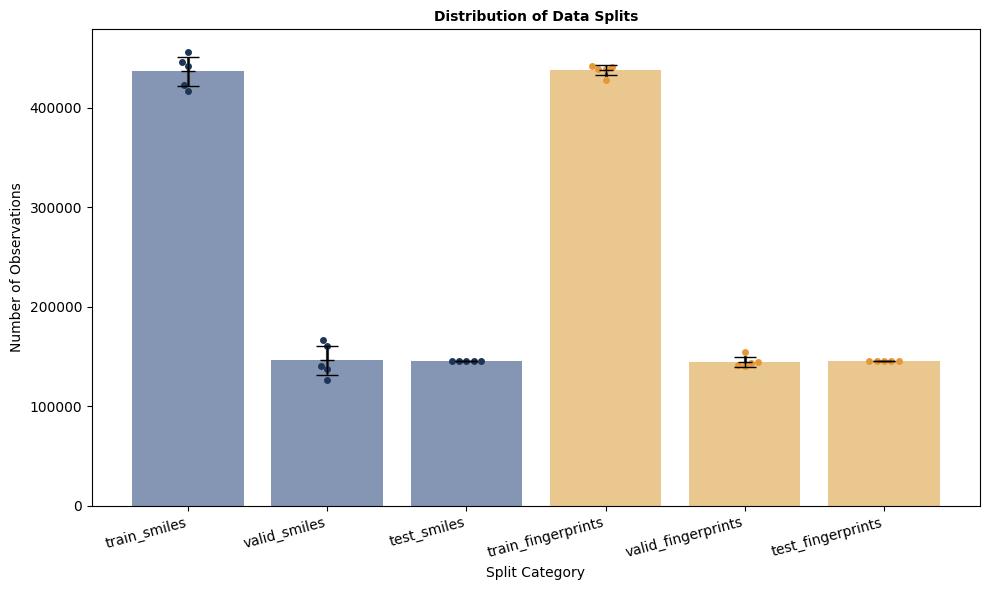

In [52]:
plt.figure(figsize=(10, 6))

bar_colors = {"smiles": "#7c94bb", "fingerprints": "#f8ca80"}   
dot_colors = {"smiles": "#1d3557", "fingerprints": "#e69839"}   

# 2. Extract unique categories in order
categories = df_swarmplot["split_type"].unique()

# 3. Plot each category column individually
for i, cat in enumerate(categories):
    dtype = "smiles" if "smiles" in cat else "fingerprints"
    sub_df = df_swarmplot[df_swarmplot["split_type"] == cat]
    values = sub_df["observation_count"].to_numpy()
    
    # Draw the swarm dots for this column
    sns.swarmplot(
        data=sub_df,
        x="split_type",
        y="observation_count",
        color=dot_colors[dtype],
        #size=6,
    )

    # Draw bar for this column
    sns.barplot(
        data=sub_df,
        x="split_type",
        y="observation_count",
        color=bar_colors[dtype],
    )
    
    # Calculate Summary Statistics: Mean and Standard Deviation
    group_mean = np.mean(values)
    std_val = np.std(values)  # Direct standard deviation calculation
    
    # 4. Draw the separate error bars (Mean and 1 SD)
    plt.errorbar(
        x=i, 
        y=group_mean, 
        yerr=std_val,                  
        fmt='_',                       
        color="black", 
        markersize=10,                 
        markeredgewidth=1,            
        elinewidth=1,                
        capsize=8,                     
        capthick=2,                    
        zorder=3                       
    )

# 5. Clean up layout aesthetics
plt.xticks(rotation=15, ha="right")
plt.title("Distribution of Data Splits", fontsize=10, fontweight="bold")
plt.ylabel("Number of Observations")
plt.xlabel("Split Category")


plt.tight_layout()
plt.show()